# Assignment 2 – Data Exploration: Student Insomnia & Educational Outcomes

**Research Question:** How does insomnia and sleep quality affect students' academic performance, and what lifestyle factors (caffeine, screen time, exercise, stress) mediate this relationship?

This notebook creates multiple exploratory visualizations of the survey dataset to identify patterns and interesting stories in the data.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

# Style
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Load data (version-2 has more responses)
df = pd.read_csv(
    '../Student Insomnia and Educational Outcomes Dataset/Student Insomnia and Educational Outcomes Dataset_version-2.csv'
)

# Shorten column names for convenience
df.columns = [
    'Timestamp', 'Year', 'Gender', 'Difficulty_Falling_Asleep',
    'Sleep_Hours', 'Wake_Up_Night', 'Sleep_Quality',
    'Difficulty_Concentrating', 'Fatigue', 'Skip_Classes',
    'Impact_Assignments', 'Device_Before_Sleep', 'Caffeine',
    'Physical_Activity', 'Stress', 'Academic_Performance'
]

print(f"Dataset: {df.shape[0]} responses, {df.shape[1]} columns")
df.head(3)

Dataset: 996 responses, 16 columns


,Timestamp,Year,Gender,Difficulty_Falling_Asleep,Sleep_Hours,Wake_Up_Night,Sleep_Quality,Difficulty_Concentrating,Fatigue,Skip_Classes,Impact_Assignments,Device_Before_Sleep,Caffeine,Physical_Activity,Stress,Academic_Performance
0,10/24/2024 16:51:15,Graduate student,Male,Often (5-6 times a week),7-8 hours,Often (5-6 times a week),Good,Sometimes,Often,Often (3-4 times a week),Moderate impact,Often (5-6 times a week),Rarely (1-2 times a week),Sometimes (3-4 times a week),High stress,Average
1,10/24/2024 16:51:51,Third year,Male,Often (5-6 times a week),7-8 hours,Often (5-6 times a week),Good,Often,Sometimes,Sometimes (1-2 times a week),Major impact,Sometimes (3-4 times a week),Sometimes (3-4 times a week),Sometimes (3-4 times a week),Low stress,Good
2,10/24/2024 16:52:21,First year,Female,Sometimes (3-4 times a week),7-8 hours,Sometimes (3-4 times a week),Good,Often,Often,Sometimes (1-2 times a week),Major impact,Often (5-6 times a week),Often (5-6 times a week),Often (5-6 times a week),High stress,Below Average


In [17]:
df['Fatigue'].value_counts()

Fatigue
Often        470
Always       329
Sometimes    132
Rarely        41
Never         24
Name: count, dtype: int64

In [3]:
# ── Define ordinal orderings for all categorical variables ──

freq_order = ['Never', 'Rarely (1-2 times a week)', 'Rarely (1-2 times a month)',
              'Sometimes (1-2 times a week)', 'Sometimes (3-4 times a week)',
              'Often (5-6 times a week)', 'Every night', 'Every day', 'Always']

# Simplified frequency labels for shorter axes
freq_short = {
    'Never': 'Never',
    'Rarely (1-2 times a week)': 'Rarely',
    'Rarely (1-2 times a month)': 'Rarely/mo',
    'Sometimes (1-2 times a week)': 'Sometimes 1-2',
    'Sometimes (3-4 times a week)': 'Sometimes 3-4',
    'Often (5-6 times a week)': 'Often',
    'Every night': 'Every night',
    'Every day': 'Every day',
    'Always': 'Always'
}

sleep_hours_order = ['Less than 4 hours', '4-5 hours', '5-6 hours',
                     '6-7 hours', '7-8 hours', 'More than 8 hours']

quality_order = ['Very poor', 'Poor', 'Average', 'Good', 'Very good', 'Excellent']

stress_order = ['No stress', 'Low stress', 'Moderate stress',
                'High stress', 'Extremely high stress']

perf_order = ['Poor', 'Below Average', 'Average', 'Good', 'Excellent']

impact_order = ['No impact', 'Minor impact', 'Moderate impact', 'Major impact']

year_order = ['First year', 'Second year', 'Third year', 'Graduate student']

# Assign numeric scores for correlation analysis
perf_score = {'Poor': 1, 'Below Average': 2, 'Average': 3, 'Good': 4, 'Excellent': 5}
quality_score = {'Very poor': 1, 'Poor': 2, 'Average': 3, 'Good': 4, 'Very good': 5, 'Excellent': 6}
stress_score = {'No stress': 1, 'Low stress': 2, 'Moderate stress': 3, 'High stress': 4, 'Extremely high stress': 5}
impact_score = {'No impact': 0, 'Minor impact': 1, 'Moderate impact': 2, 'Major impact': 3}

df['perf_num'] = df['Academic_Performance'].map(perf_score)
df['quality_num'] = df['Sleep_Quality'].map(quality_score)
df['stress_num'] = df['Stress'].map(stress_score)
df['impact_num'] = df['Impact_Assignments'].map(impact_score)

print("Ordinal encodings ready.")
print(f"\nAcademic Performance distribution:\n{df['Academic_Performance'].value_counts()}")
print(f"\nSleep Quality distribution:\n{df['Sleep_Quality'].value_counts()}")

Ordinal encodings ready.

Academic Performance distribution:
Academic_Performance
Poor             491
Below Average    388
Average           76
Good              29
Excellent         12
Name: count, dtype: int64

Sleep Quality distribution:
Sleep_Quality
Very poor    290
Very good    251
Good         214
Poor         166
Average       75
Name: count, dtype: int64


---
## Visualization 1 – Sleep Quality vs Academic Performance (Heatmap)
**Data attributes:** Sleep Quality × Academic Performance  
**Caption:** This heatmap shows the joint distribution of self-reported sleep quality and academic performance. Each cell displays the count of students in that combination. The visualization reveals whether students who rate their sleep higher also tend to report better grades.

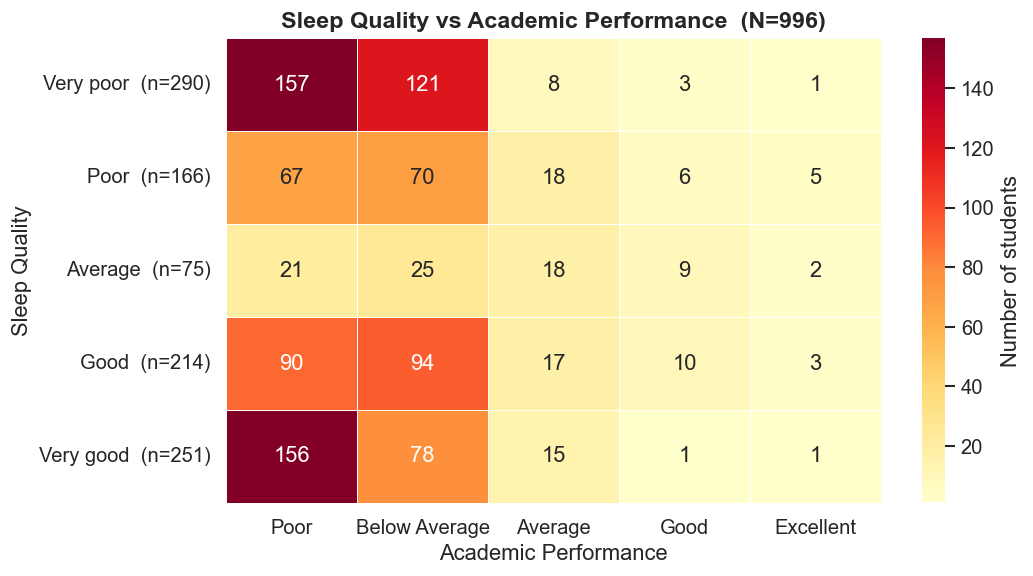

In [4]:
ct = pd.crosstab(
    df['Sleep_Quality'],
    df['Academic_Performance']
)

# Reindex to ensure correct order
ct = ct.reindex(index=[q for q in quality_order if q in ct.index],
                columns=[p for p in perf_order if p in ct.columns])

# Add row sample sizes to y-axis labels
row_totals = ct.sum(axis=1)
ct.index = [f"{q}  (n={int(row_totals[q])})" for q in ct.index]

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', linewidths=.5,
            cbar_kws={'label': 'Number of students'}, ax=ax)
ax.set_title(f'Sleep Quality vs Academic Performance  (N={int(row_totals.sum())})',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Sleep Quality')
ax.set_xlabel('Academic Performance')
plt.tight_layout()
plt.savefig('viz1_sleep_quality_vs_performance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Visualization 2 – Sleep Duration Distribution by Year of Study
**Data attributes:** Sleep Hours × Year of Study  
**Caption:** This grouped bar chart shows how average sleep duration varies across academic years. It reveals whether first-year students sleep differently than seniors or graduate students, and highlights potential lifestyle shifts as students progress through their education.

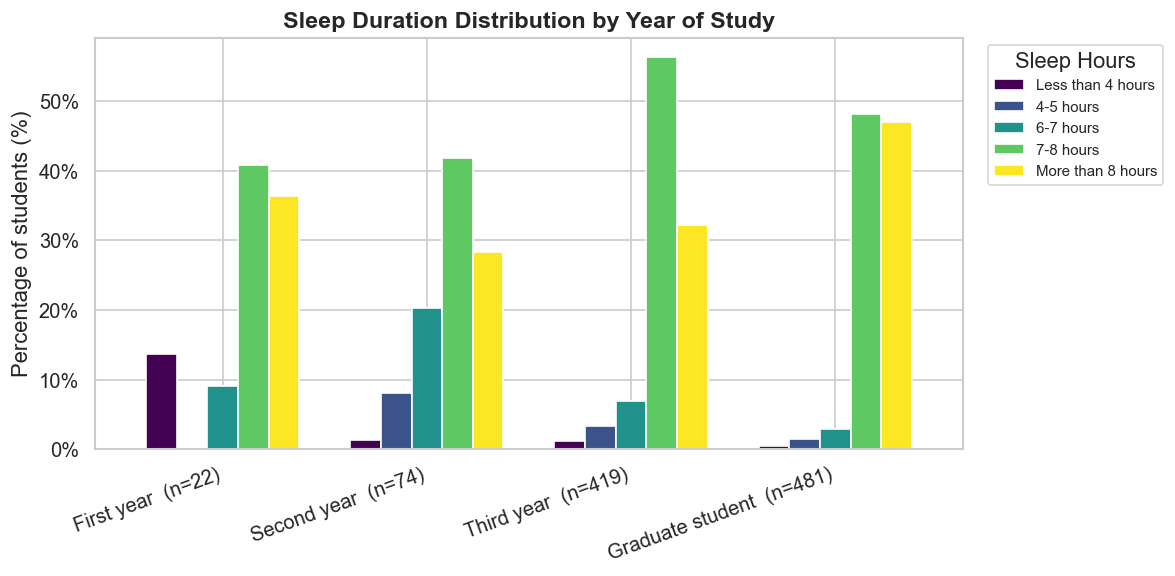

In [5]:
ct2_raw = pd.crosstab(df['Year'], df['Sleep_Hours'])
ct2 = pd.crosstab(df['Year'], df['Sleep_Hours'], normalize='index') * 100

# Keep only existing values in order
cols = [h for h in sleep_hours_order if h in ct2.columns]
rows = [y for y in year_order if y in ct2.index]
ct2 = ct2.reindex(index=rows, columns=cols)
ct2_raw = ct2_raw.reindex(index=rows, columns=cols)

# Add sample sizes to year labels
year_n = ct2_raw.sum(axis=1)
ct2.index = [f"{y}  (n={int(year_n[y])})" for y in ct2.index]

fig, ax = plt.subplots(figsize=(10, 5))
ct2.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='white', width=0.75)
ax.set_title('Sleep Duration Distribution by Year of Study', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage of students (%)')
ax.set_xlabel('')
ax.legend(title='Sleep Hours', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.savefig('viz2_sleep_hours_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Visualization 3 – Stress Levels vs Insomnia Frequency
**Data attributes:** Academic Stress × Difficulty Falling Asleep  
**Caption:** This stacked percentage bar chart shows the relationship between academic stress levels and the frequency of difficulty falling asleep. Higher stress categories show a clear shift towards more frequent insomnia, suggesting a strong association between academic pressure and sleep problems.

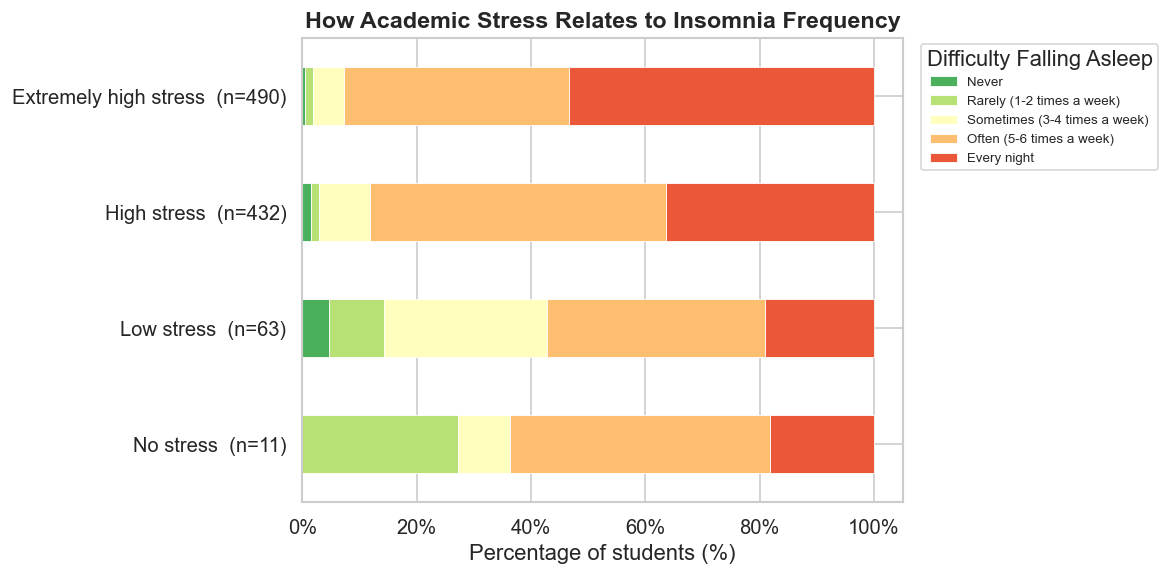

In [6]:
ct3_raw = pd.crosstab(df['Stress'], df['Difficulty_Falling_Asleep'])
ct3 = pd.crosstab(df['Stress'], df['Difficulty_Falling_Asleep'], normalize='index') * 100

insomnia_cols = [f for f in freq_order if f in ct3.columns]
stress_rows = [s for s in stress_order if s in ct3.index]
ct3 = ct3.reindex(index=stress_rows, columns=insomnia_cols)
ct3_raw = ct3_raw.reindex(index=stress_rows, columns=insomnia_cols)

# Add sample sizes to stress labels
stress_n = ct3_raw.sum(axis=1)
ct3.index = [f"{s}  (n={int(stress_n[s])})" for s in ct3.index]

colors = sns.color_palette('RdYlGn_r', len(insomnia_cols))

fig, ax = plt.subplots(figsize=(10, 5))
ct3.plot(kind='barh', stacked=True, ax=ax, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('How Academic Stress Relates to Insomnia Frequency', fontsize=14, fontweight='bold')
ax.set_xlabel('Percentage of students (%)')
ax.set_ylabel('')
ax.legend(title='Difficulty Falling Asleep', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.savefig('viz3_stress_vs_insomnia.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Visualization 4 – Caffeine Consumption vs Sleep Quality
**Data attributes:** Caffeine Consumption × Sleep Quality  
**Caption:** This chart explores whether students who consume caffeine more frequently report worse sleep quality. The bars show the mean sleep quality score for each caffeine-usage level. A downward trend would suggest caffeine use is associated with poorer sleep.

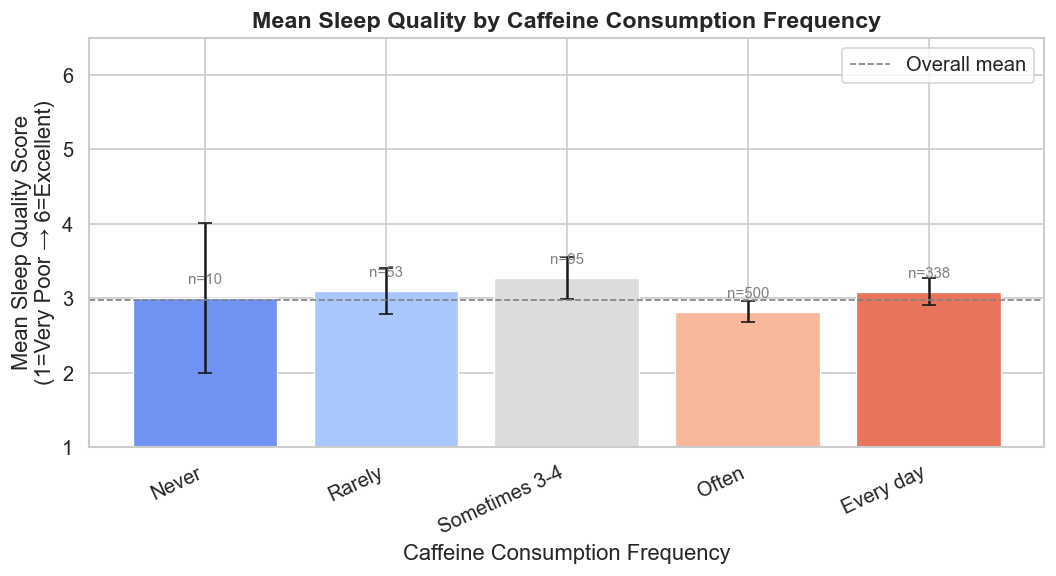

In [7]:
caff_order_present = [f for f in freq_order if f in df['Caffeine'].unique()]
caff_labels = [freq_short.get(f, f) for f in caff_order_present]

caff_quality = df.groupby('Caffeine')['quality_num'].agg(['mean', 'count', 'sem']).reindex(caff_order_present)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(caff_labels, caff_quality['mean'],
              yerr=caff_quality['sem'] * 1.96, capsize=4,
              color=sns.color_palette('coolwarm', len(caff_labels)),
              edgecolor='white', linewidth=0.8)

# Add count labels on bars
for bar, n in zip(bars, caff_quality['count']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f'n={int(n)}', ha='center', va='bottom', fontsize=9, color='gray')

ax.set_title('Mean Sleep Quality by Caffeine Consumption Frequency',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Sleep Quality Score\n(1=Very Poor → 6=Excellent)')
ax.set_xlabel('Caffeine Consumption Frequency')
ax.set_ylim(1, 6.5)
ax.axhline(y=df['quality_num'].mean(), color='gray', ls='--', lw=1, label='Overall mean')
ax.legend()
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('viz4_caffeine_vs_sleep_quality.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Visualization 5 – Impact of Sleep on Assignments by Academic Performance
**Data attributes:** Academic Performance × Impact on Assignments  
**Caption:** This 100% stacked bar chart shows how students at each performance level describe the impact of poor sleep on their ability to complete assignments. It reveals that lower-performing students are more likely to report "Major impact", while higher-performing students cluster around "Minor" or "No impact".

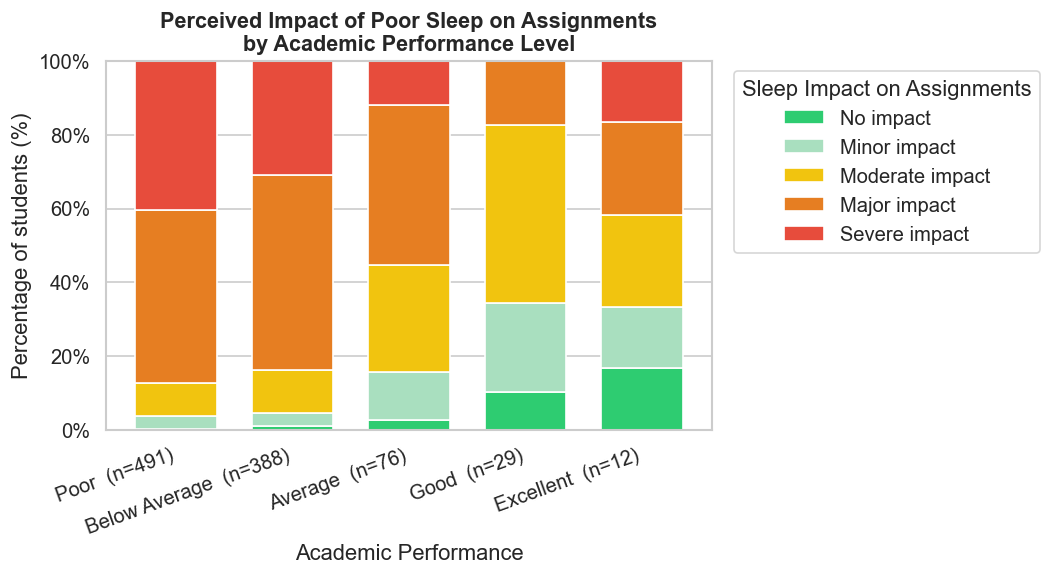

In [8]:
impact_order_full = ['No impact', 'Minor impact', 'Moderate impact', 'Major impact', 'Severe impact']

ct5_raw = pd.crosstab(df['Academic_Performance'], df['Impact_Assignments'])
ct5 = pd.crosstab(df['Academic_Performance'], df['Impact_Assignments'],
                   normalize='index') * 100
impact_cols = [i for i in impact_order_full if i in ct5.columns]
perf_rows = [p for p in perf_order if p in ct5.index]
ct5 = ct5.reindex(index=perf_rows, columns=impact_cols)
ct5_raw = ct5_raw.reindex(index=perf_rows, columns=impact_cols)

# Add sample sizes to performance labels
perf_n = ct5_raw.sum(axis=1)
ct5.index = [f"{p}  (n={int(perf_n[p])})" for p in ct5.index]

colors5 = ['#2ecc71', '#a9dfbf', '#f1c40f', '#e67e22', '#e74c3c']

fig, ax = plt.subplots(figsize=(9, 5))
ct5.plot(kind='bar', stacked=True, ax=ax, color=colors5[:len(impact_cols)],
         edgecolor='white', width=0.7)
ax.set_title('Perceived Impact of Poor Sleep on Assignments\nby Academic Performance Level',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Percentage of students (%)')
ax.set_xlabel('Academic Performance')
ax.legend(title='Sleep Impact on Assignments', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.savefig('viz5_impact_by_performance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Visualization 6 – Gender Differences in Key Sleep & Academic Metrics
**Data attributes:** Gender × Sleep Quality, Stress, Academic Performance (multi-metric comparison)  
**Caption:** This grouped bar chart compares the mean scores for sleep quality, stress level, and academic performance between male and female students. It highlights whether there are notable gender disparities in these key dimensions of the insomnia-education relationship.

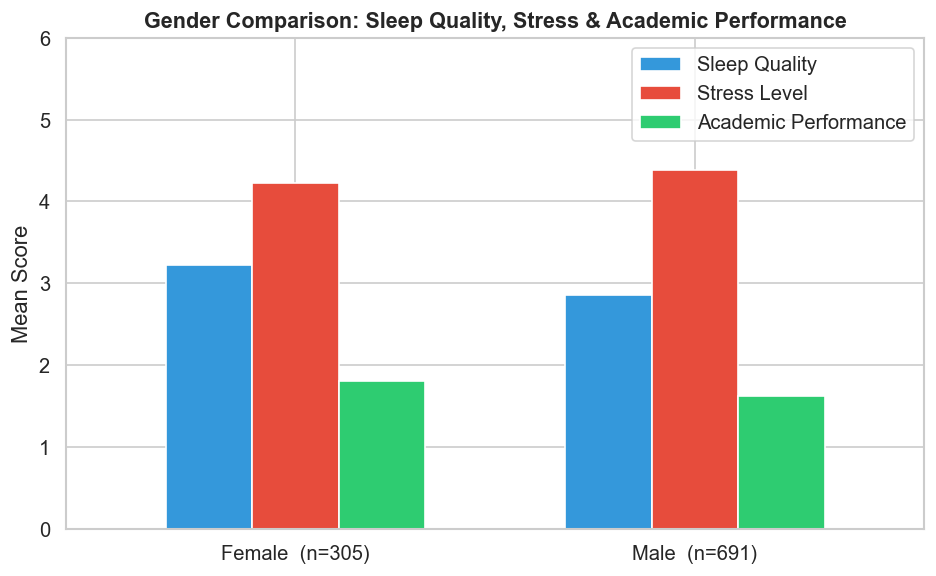

In [9]:
gender_counts = df['Gender'].value_counts()
gender_means = df.groupby('Gender')[['quality_num', 'stress_num', 'perf_num']].mean()
gender_means.columns = ['Sleep Quality', 'Stress Level', 'Academic Performance']

# Only keep Male/Female if present
gender_means = gender_means.loc[gender_means.index.isin(['Male', 'Female'])]

# Add sample sizes to gender labels
gender_means.index = [f"{g}  (n={int(gender_counts[g])})" for g in gender_means.index]

fig, ax = plt.subplots(figsize=(8, 5))
gender_means.plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c', '#2ecc71'],
                  edgecolor='white', width=0.65)
ax.set_title('Gender Comparison: Sleep Quality, Stress & Academic Performance',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Score')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc='upper right')
ax.set_ylim(0, 6)
plt.tight_layout()
plt.savefig('viz6_gender_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Visualization 7 – Screen Time Before Bed vs Sleep Quality
**Data attributes:** Electronic Device Usage Before Sleep × Sleep Quality  
**Caption:** This heatmap shows the joint distribution of pre-sleep electronic device usage and sleep quality ratings. It tests the hypothesis that more frequent screen time before bed leads to poorer sleep quality among students.

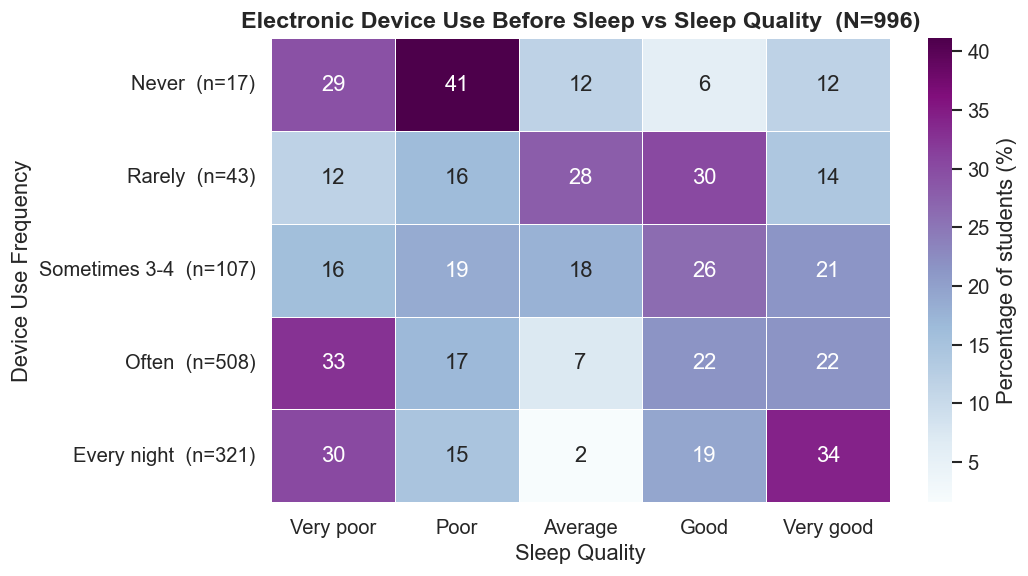

In [10]:
ct7_raw = pd.crosstab(df['Device_Before_Sleep'], df['Sleep_Quality'])
ct7 = pd.crosstab(df['Device_Before_Sleep'], df['Sleep_Quality'], normalize='index') * 100

device_rows = [f for f in freq_order if f in ct7.index]
quality_cols = [q for q in quality_order if q in ct7.columns]
ct7 = ct7.reindex(index=device_rows, columns=quality_cols)
ct7_raw = ct7_raw.reindex(index=device_rows, columns=quality_cols)

# Add row sample sizes, then shorten labels
row_totals7 = ct7_raw.sum(axis=1)
ct7.index = [f"{freq_short.get(i, i)}  (n={int(row_totals7[i])})" for i in ct7.index]

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(ct7, annot=True, fmt='.0f', cmap='BuPu', linewidths=.5,
            cbar_kws={'label': 'Percentage of students (%)'}, ax=ax)
ax.set_title(f'Electronic Device Use Before Sleep vs Sleep Quality  (N={int(row_totals7.sum())})',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Device Use Frequency')
ax.set_xlabel('Sleep Quality')
plt.tight_layout()
plt.savefig('viz7_device_vs_sleep_quality.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Visualization 8 – Physical Activity vs Academic Performance
**Data attributes:** Physical Activity Frequency × Academic Performance  
**Caption:** This chart shows mean academic performance scores across different levels of physical activity. It tests whether regular exercise is associated with better grades, even indirectly through improved sleep or reduced stress.

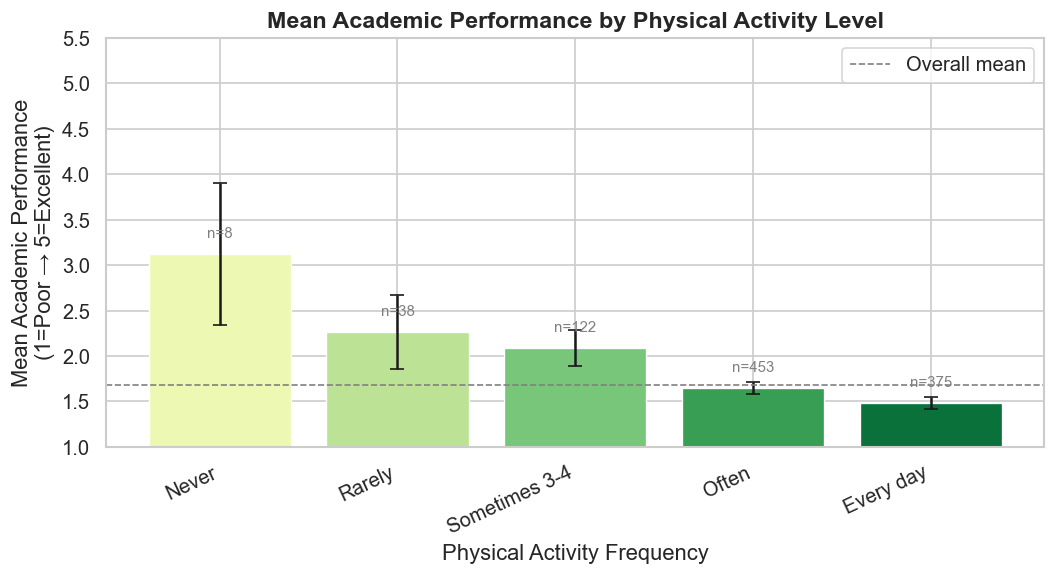

In [11]:
activity_order_present = [f for f in freq_order if f in df['Physical_Activity'].unique()]
activity_labels = [freq_short.get(f, f) for f in activity_order_present]

act_perf = df.groupby('Physical_Activity')['perf_num'].agg(['mean', 'count', 'sem']).reindex(activity_order_present)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(activity_labels, act_perf['mean'],
              yerr=act_perf['sem'] * 1.96, capsize=4,
              color=sns.color_palette('YlGn', len(activity_labels)),
              edgecolor='white', linewidth=0.8)

# Add count labels on bars
for bar, n in zip(bars, act_perf['count']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f'n={int(n)}', ha='center', va='bottom', fontsize=9, color='gray')

ax.set_title('Mean Academic Performance by Physical Activity Level',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Academic Performance\n(1=Poor → 5=Excellent)')
ax.set_xlabel('Physical Activity Frequency')
ax.set_ylim(1, 5.5)
ax.axhline(y=df['perf_num'].mean(), color='gray', ls='--', lw=1, label='Overall mean')
ax.legend()
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('viz8_activity_vs_performance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Visualization 9 – Concentration Difficulty by Sleep Hours (Diverging Stacked Bar)
**Data attributes:** Sleep Hours × Difficulty Concentrating  
**Caption:** This chart shows how the frequency of concentration difficulties varies across sleep-duration groups. Students sleeping fewer hours report more frequent difficulty concentrating in lectures and while studying, directly connecting sleep quantity to cognitive performance.

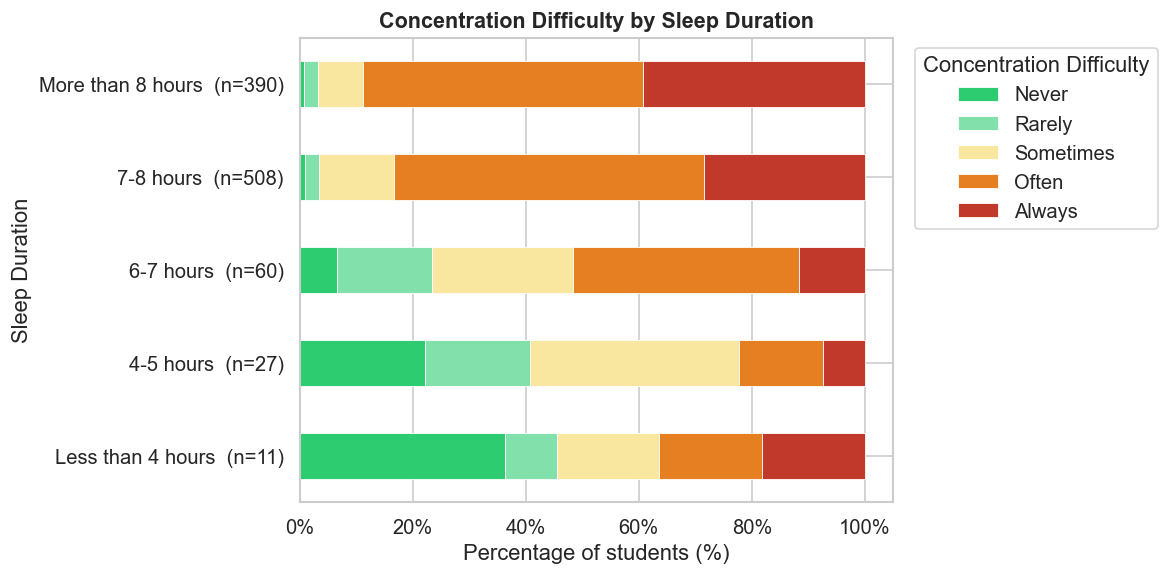

In [12]:
conc_order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Always']

# Raw counts & percentages
ct9_raw = pd.crosstab(df['Sleep_Hours'], df['Difficulty_Concentrating'])
ct9 = pd.crosstab(df['Sleep_Hours'], df['Difficulty_Concentrating'], normalize='index') * 100

hours_rows = [h for h in sleep_hours_order if h in ct9.index]
conc_cols = [c for c in conc_order if c in ct9.columns]
ct9 = ct9.reindex(index=hours_rows, columns=conc_cols).fillna(0)
ct9_raw = ct9_raw.reindex(index=hours_rows, columns=conc_cols).fillna(0)

# Get sample sizes per sleep-hours group
sample_sizes = ct9_raw.sum(axis=1)

# Relabel rows with sample size for transparency
ct9.index = [f"{h}  (n={int(sample_sizes[h])})" for h in ct9.index]

colors9 = ['#2ecc71', '#82e0aa', '#f9e79f', '#e67e22', '#c0392b']

fig, ax = plt.subplots(figsize=(10, 5))
ct9.plot(kind='barh', stacked=True, ax=ax,
         color=colors9[:len(conc_cols)], edgecolor='white', linewidth=0.5)
ax.set_title('Concentration Difficulty by Sleep Duration',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Percentage of students (%)')
ax.set_ylabel('Sleep Duration')
ax.legend(title='Concentration Difficulty', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.savefig('viz9_concentration_by_sleep_hours.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Visualization 10 – Correlation Matrix of All Numeric-Encoded Variables
**Data attributes:** All key variables (sleep quality, stress, performance, impact) encoded numerically  
**Caption:** This correlation heatmap provides an overview of the pairwise relationships between the key ordinal variables. Stronger positive or negative correlations point to which factors are most tightly linked — for example, whether stress has a stronger link to poor performance than sleep quality does.

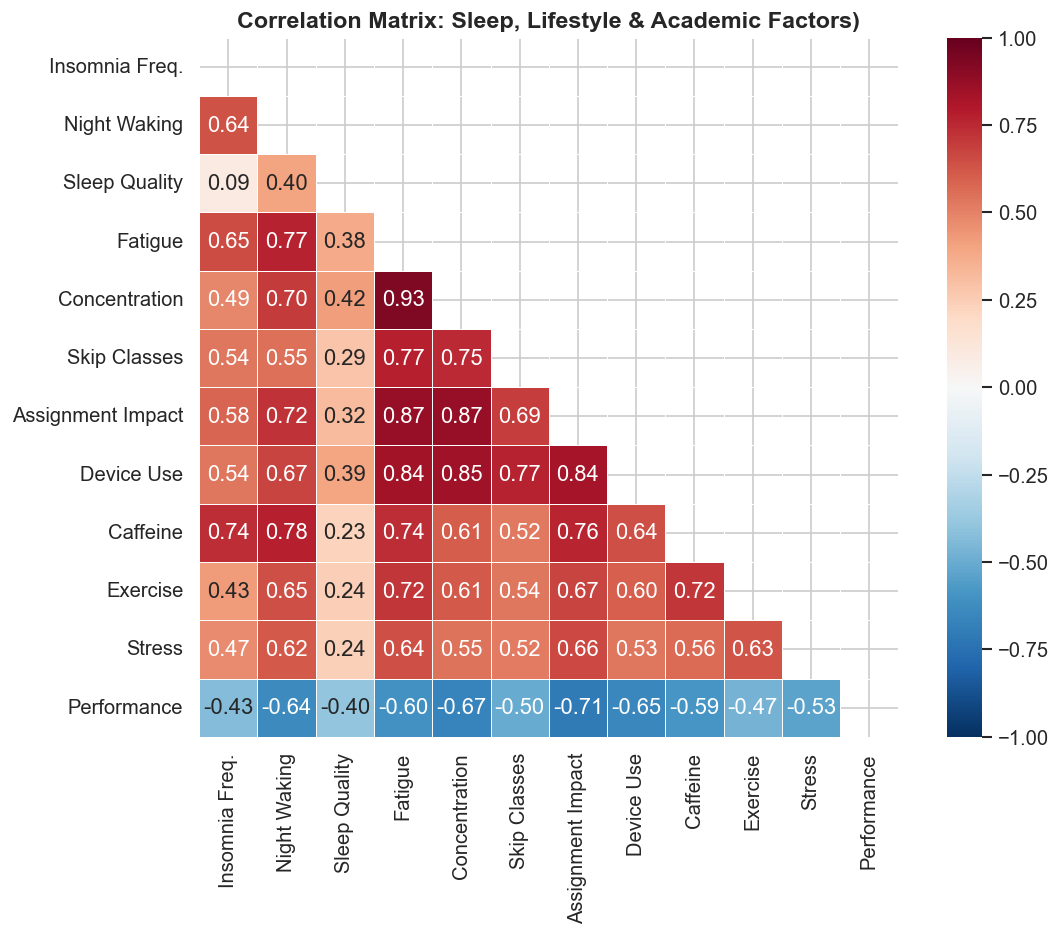

In [13]:
# Encode more variables numerically
freq_score = {
    'Never': 0, 'Rarely (1-2 times a month)': 1, 'Rarely (1-2 times a week)': 1,
    'Sometimes (1-2 times a week)': 2, 'Sometimes (3-4 times a week)': 3,
    'Often (5-6 times a week)': 4, 'Every night': 5, 'Every day': 5, 'Always': 6
}

df['insomnia_num'] = df['Difficulty_Falling_Asleep'].map(freq_score)
df['wakeup_num'] = df['Wake_Up_Night'].map(freq_score)
df['fatigue_num'] = df['Fatigue'].map(freq_score)
df['skip_num'] = df['Skip_Classes'].map(freq_score)
df['device_num'] = df['Device_Before_Sleep'].map(freq_score)
df['caffeine_num'] = df['Caffeine'].map(freq_score)
df['activity_num'] = df['Physical_Activity'].map(freq_score)
df['concentration_num'] = df['Difficulty_Concentrating'].map(freq_score)

corr_vars = {
    'Insomnia Freq.': 'insomnia_num',
    'Night Waking': 'wakeup_num',
    'Sleep Quality': 'quality_num',
    'Fatigue': 'fatigue_num',
    'Concentration': 'concentration_num',
    'Skip Classes': 'skip_num',
    'Assignment Impact': 'impact_num',
    'Device Use': 'device_num',
    'Caffeine': 'caffeine_num',
    'Exercise': 'activity_num',
    'Stress': 'stress_num',
    'Performance': 'perf_num'
}

corr_df = df[[v for v in corr_vars.values()]].dropna()
corr_df.columns = list(corr_vars.keys())
corr_matrix = corr_df.corr()
n_corr = len(corr_df)

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=.5,
            square=True, ax=ax)
ax.set_title(f'Correlation Matrix: Sleep, Lifestyle & Academic Factors)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz10_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Visualization 11 (Bonus) – Class Skipping by Sleep Quality and Stress
**Data attributes:** Sleep Quality × Stress Level × Class Skipping  
**Caption:** This faceted chart shows mean class-skipping scores across sleep quality and stress combinations. It reveals the combined effect: students with both poor sleep *and* high stress skip the most classes.

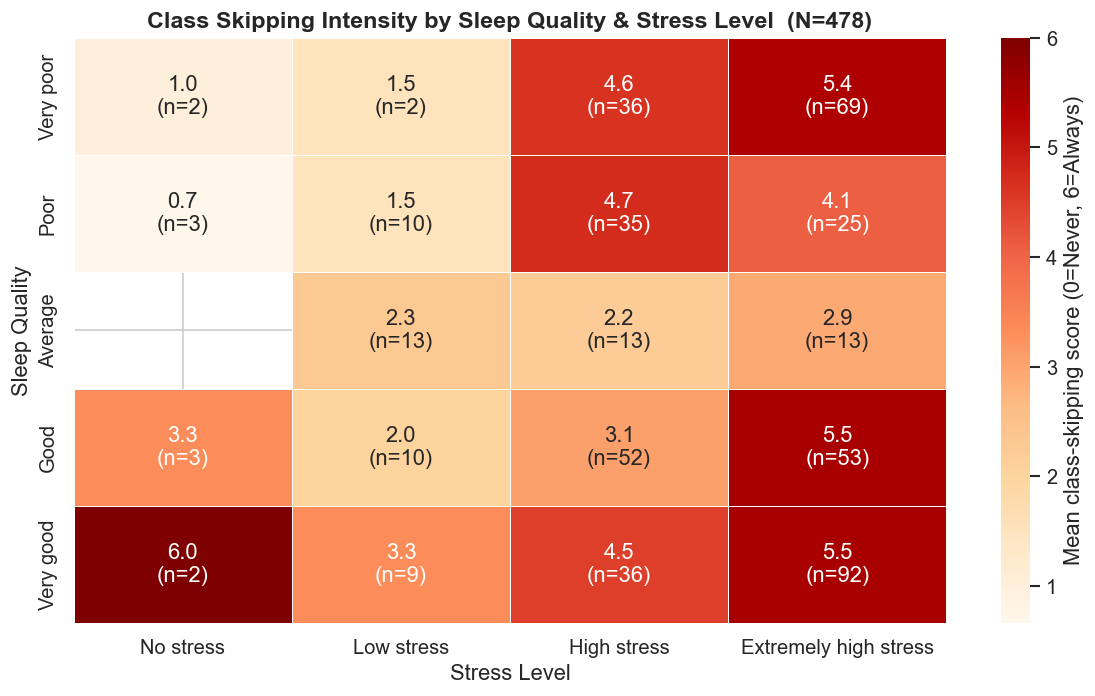

In [14]:
# Pivot: mean skip score by sleep quality and stress
skip_pivot = df.pivot_table(values='skip_num', index='Sleep_Quality',
                            columns='Stress', aggfunc='mean')
# Also get counts per cell
skip_counts = df.pivot_table(values='skip_num', index='Sleep_Quality',
                             columns='Stress', aggfunc='count')

sq_rows = [q for q in quality_order if q in skip_pivot.index]
st_cols = [s for s in stress_order if s in skip_pivot.columns]
skip_pivot = skip_pivot.reindex(index=sq_rows, columns=st_cols)
skip_counts = skip_counts.reindex(index=sq_rows, columns=st_cols).fillna(0)

# Build annotation labels: "mean\n(n=count)"
annot_labels = skip_pivot.copy().astype(str)
for r in annot_labels.index:
    for c in annot_labels.columns:
        val = skip_pivot.loc[r, c]
        cnt = int(skip_counts.loc[r, c])
        annot_labels.loc[r, c] = f'{val:.1f}\n(n={cnt})' if not pd.isna(val) else ''

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(skip_pivot, annot=annot_labels, fmt='', cmap='OrRd', linewidths=.5,
            cbar_kws={'label': 'Mean class-skipping score (0=Never, 6=Always)'}, ax=ax)
ax.set_title(f'Class Skipping Intensity by Sleep Quality & Stress Level  (N={int(skip_counts.sum().sum())})',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Sleep Quality')
ax.set_xlabel('Stress Level')
plt.tight_layout()
plt.savefig('viz11_skip_classes_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary of Visualizations for Assignment Selection

| # | Visualization | Key Attributes | Potential Use for Slides |
|---|---|---|---|
| 1 | Sleep Quality vs Academic Performance (Heatmap) | Sleep Quality × Performance | Core finding |
| 2 | Sleep Duration by Year of Study | Sleep Hours × Year | Demographic lens |
| 3 | Stress vs Insomnia Frequency | Stress × Insomnia | Causal pathway |
| 4 | Caffeine vs Sleep Quality | Caffeine × Sleep Quality | Lifestyle factor |
| 5 | Impact on Assignments by Performance | Performance × Assignment Impact | Consequences |
| 6 | Gender Comparison | Gender × Multi-metric | Equity lens |
| 7 | Device Use vs Sleep Quality | Screen Time × Sleep Quality | Lifestyle factor |
| 8 | Physical Activity vs Performance | Exercise × Performance | Lifestyle factor |
| 9 | Concentration by Sleep Hours | Sleep Hours × Concentration | Mechanism |
| 10 | Correlation Matrix | All variables | Big picture |
| 11 | Class Skipping by Sleep Quality & Stress | Sleep Quality × Stress × Skipping | Combined effect |

**Pick any 5 that together tell a coherent story. Suggested narrative:**
1. Viz 3 (Stress → Insomnia) → 2. Viz 1 (Sleep Quality → Performance) → 3. Viz 9 (Sleep Hours → Concentration) → 4. Viz 5 (Impact → Assignments) → 5. Viz 10 (Big picture correlations)